# <span style="color: gold;">Semantics in AI</span>
| Field | Value |
| --- | --- |
| Author | Sarbjit Sarkaria |
| Date | April 2026 |
| Description | This notebook demonstrates how to use embedding vectors to capture semantic relationships in AI models. We will explore how to create and search text embedding vectors using a simple example. |


In [10]:
# Requires transformers>=4.51.0
# Requires sentence-transformers>=2.7.0

from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

# We recommend enabling flash_attention_2 for better acceleration and memory saving,
# together with setting `padding_side` to "left":
# model = SentenceTransformer(
#     "Qwen/Qwen3-Embedding-0.6B",
#     model_kwargs={"attn_implementation": "flash_attention_2", "device_map": "auto"},
#     tokenizer_kwargs={"padding_side": "left"},
# )

# The queries and documents to embed
queries = [
    "What is the capital of China?",
    "Explain gravity",
]
documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. It gives weight to physical objects and is responsible for the movement of planets around the sun.",
]

# Encode the queries and documents. Note that queries benefit from using a prompt
# Here we use the prompt called "query" stored under `model.prompts`, but you can
# also pass your own prompt via the `prompt` argument
query_embeddings = model.encode(queries, prompt_name="query")
document_embeddings = model.encode(documents)

# Compute the (cosine) similarity between the query and document embeddings
similarity = model.similarity(query_embeddings, document_embeddings)
print(similarity)
# tensor([[0.7646, 0.1414],
#         [0.1355, 0.6000]])


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

tensor([[0.7612, 0.1407],
        [0.1363, 0.5984]])


## <span style="color: gold;">Example: Searching Text</span>

**Notes**
* Here we would like demonstrate how embedding vectors can be used to search for relevant documents given a query. We will use the cosine similarity between the query and document embeddings to rank the documents based on their relevance to the query.

**Instructions**
1. Create a list of _documents_ that are to be searched. These can be short sentences on various random topics
2. Create a list of sample _queries_ that might be used to search for the documents.
   - There should be some queries that are relevant to the documents and some that are not.
3. Using the `model.encode` method, create embedding vectors for both the documents and the queries.
4. Compute the cosine similarity between the query embeddings and the document embeddings using the `model.similarity` method.
5. Print the similarity scores to see which documents are most relevant to each query in a list
6. Show a nicely formatted summary that identifies the matching document.

**Data**

```
documents = [
    "The Eiffel Tower is located in Paris and was completed in 1889.",
    "Photosynthesis allows plants to convert sunlight, water, and carbon dioxide into energy.",
    "Python is a popular programming language used for web development, data science, and automation.",
    "Mount Everest is the highest mountain above sea level on Earth.",
    "Octopuses are highly intelligent marine animals with eight arms and remarkable camouflage abilities.",
    "Basketball is a team sport in which players score points by shooting a ball through a hoop.",
]

queries = [
    "Where is the Eiffel Tower located?",
    "How do plants make food from sunlight?",
    "What is the tallest mountain in the world?",
    "Tell me about the Python programming language.",
    "How do you bake sourdough bread?",
    "What causes thunderstorms to form?",
]
```


In [11]:
documents = [
    "The Eiffel Tower is located in Paris and was completed in 1889.",
    "Photosynthesis allows plants to convert sunlight, water, and carbon dioxide into energy.",
    "Python is a popular programming language used for web development, data science, and automation.",
    "Mount Everest is the highest mountain above sea level on Earth.",
    "Octopuses are highly intelligent marine animals with eight arms and remarkable camouflage abilities.",
    "Basketball is a team sport in which players score points by shooting a ball through a hoop.",
]

queries = [
    "Where is the Eiffel Tower located?",
    "How do plants make food from sunlight?",
    "What is the tallest mountain in the world?",
    "Tell me about the Python programming language.",
    "How do you bake sourdough bread?",
    "What causes thunderstorms to form?",
]

query_embeddings = model.encode(queries, prompt_name="query")
document_embeddings = model.encode(documents)

similarity = model.similarity(query_embeddings, document_embeddings)

print("Similarity scores for each query:")
print("-" * 80)
for query_index, query in enumerate(queries):
    print(f"\nQuery: {query}")
    scores = similarity[query_index].tolist()
    for document_index, score in enumerate(scores):
        print(f"  Document {document_index + 1}: {score:.4f}")

print("\n" + "=" * 80)
print("Best matching document for each query")
print("=" * 80)
for query_index, query in enumerate(queries):
    scores = similarity[query_index].tolist()
    best_match_index = max(range(len(scores)), key=scores.__getitem__)
    best_score = scores[best_match_index]

    print(f"\nQuery: {query}")
    print(f"Best match: {documents[best_match_index]}")
    print(f"Similarity score: {best_score:.4f}")


Similarity scores for each query:
--------------------------------------------------------------------------------

Query: Where is the Eiffel Tower located?
  Document 1: 0.6814
  Document 2: 0.1020
  Document 3: 0.1104
  Document 4: 0.3351
  Document 5: 0.1254
  Document 6: 0.1822

Query: How do plants make food from sunlight?
  Document 1: 0.1208
  Document 2: 0.5939
  Document 3: 0.1217
  Document 4: 0.1246
  Document 5: 0.1690
  Document 6: 0.1563

Query: What is the tallest mountain in the world?
  Document 1: 0.3335
  Document 2: 0.0914
  Document 3: 0.1050
  Document 4: 0.6385
  Document 5: 0.1392
  Document 6: 0.1765

Query: Tell me about the Python programming language.
  Document 1: 0.1179
  Document 2: 0.1211
  Document 3: 0.6054
  Document 4: 0.1695
  Document 5: 0.1562
  Document 6: 0.2121

Query: How do you bake sourdough bread?
  Document 1: 0.0636
  Document 2: 0.1860
  Document 3: 0.1140
  Document 4: -0.0005
  Document 5: 0.0631
  Document 6: 0.1803

Query: What caus

## <span style="color: gold;">Example: Searching Text in Other Languages</span>

**Notes**
* Now we want to demonstrate how embedding vectors can be used to search in other languages.

**Instructions**
1. Using the same list of documents as before, create a new list of queries
2. The queries should have the same semantic meaning as the previous ones but should be in different languages
   - You can use French, Spanish, Italian and Japanese for the queries
3. Demonstrate searching for an English document using a query in another language and show the similarity scores for each query and the best matching document for each query.

**Data**
```
multilingual_queries = [
    "Où se trouve la tour Eiffel ?",                            # French
    "¿Cómo producen energía las plantas con la luz solar?",     # Spanish
    "Qual è la montagna più alta del mondo?",                   # Italian
    "Pythonプログラミング言語について教えてください。",                # Japanese
    "Comment faire du pain au levain ?",                        # French, unrelated
    "¿Qué causa la formación de tormentas eléctricas?",         # Spanish, unrelated
]
```

In [12]:
multilingual_queries = [
    "Où se trouve la tour Eiffel ?",                    # French
    "¿Cómo producen energía las plantas con la luz solar?",  # Spanish
    "Qual è la montagna più alta del mondo?",          # Italian
    "Pythonプログラミング言語について教えてください。",      # Japanese
    "Comment faire du pain au levain ?",               # French, unrelated
    "¿Qué causa la formación de tormentas eléctricas?", # Spanish, unrelated
]

multilingual_query_embeddings = model.encode(multilingual_queries, prompt_name="query")
multilingual_similarity = model.similarity(multilingual_query_embeddings, document_embeddings)

print("Similarity scores for multilingual queries:")
print("-" * 80)
for query_index, query in enumerate(multilingual_queries):
    print(f"\nQuery: {query}")
    scores = multilingual_similarity[query_index].tolist()
    for document_index, score in enumerate(scores):
        print(f"  Document {document_index + 1}: {score:.4f}")

print("\n" + "=" * 80)
print("Best matching document for each multilingual query")
print("=" * 80)
for query_index, query in enumerate(multilingual_queries):
    scores = multilingual_similarity[query_index].tolist()
    best_match_index = max(range(len(scores)), key=scores.__getitem__)
    best_score = scores[best_match_index]

    print(f"\nQuery: {query}")
    print(f"Best match: {documents[best_match_index]}")
    print(f"Similarity score: {best_score:.4f}")


Similarity scores for multilingual queries:
--------------------------------------------------------------------------------

Query: Où se trouve la tour Eiffel ?
  Document 1: 0.5796
  Document 2: 0.0917
  Document 3: 0.1009
  Document 4: 0.2996
  Document 5: 0.1139
  Document 6: 0.1644

Query: ¿Cómo producen energía las plantas con la luz solar?
  Document 1: 0.0997
  Document 2: 0.5977
  Document 3: 0.1223
  Document 4: 0.0824
  Document 5: 0.1405
  Document 6: 0.1365

Query: Qual è la montagna più alta del mondo?
  Document 1: 0.3178
  Document 2: 0.1390
  Document 3: 0.1673
  Document 4: 0.6895
  Document 5: 0.1857
  Document 6: 0.1846

Query: Pythonプログラミング言語について教えてください。
  Document 1: 0.1014
  Document 2: 0.0936
  Document 3: 0.5819
  Document 4: 0.1400
  Document 5: 0.1433
  Document 6: 0.1923

Query: Comment faire du pain au levain ?
  Document 1: 0.1553
  Document 2: 0.1705
  Document 3: 0.1097
  Document 4: 0.0592
  Document 5: 0.0480
  Document 6: 0.1479

Query: ¿Qué causa la

## <span style="color: gold;">Visualize Embedding Vectors</span>

**Notes**
* To help my audience better understand the concept of embedding vectors, I will visualize the query and document embeddings in a 3d space using dimensionality reduction techniques like PCA or t-SNE.

**Instructions**
1. Using `matplotlib` or `seaborn`, create a 3D scatter plot to visualize the query and document embeddings.
2. Use different colors or markers to distinguish between queries and documents in the plot.
3. Make the plot interactive, so I can turn data points on and off by clicking on items in the legend.


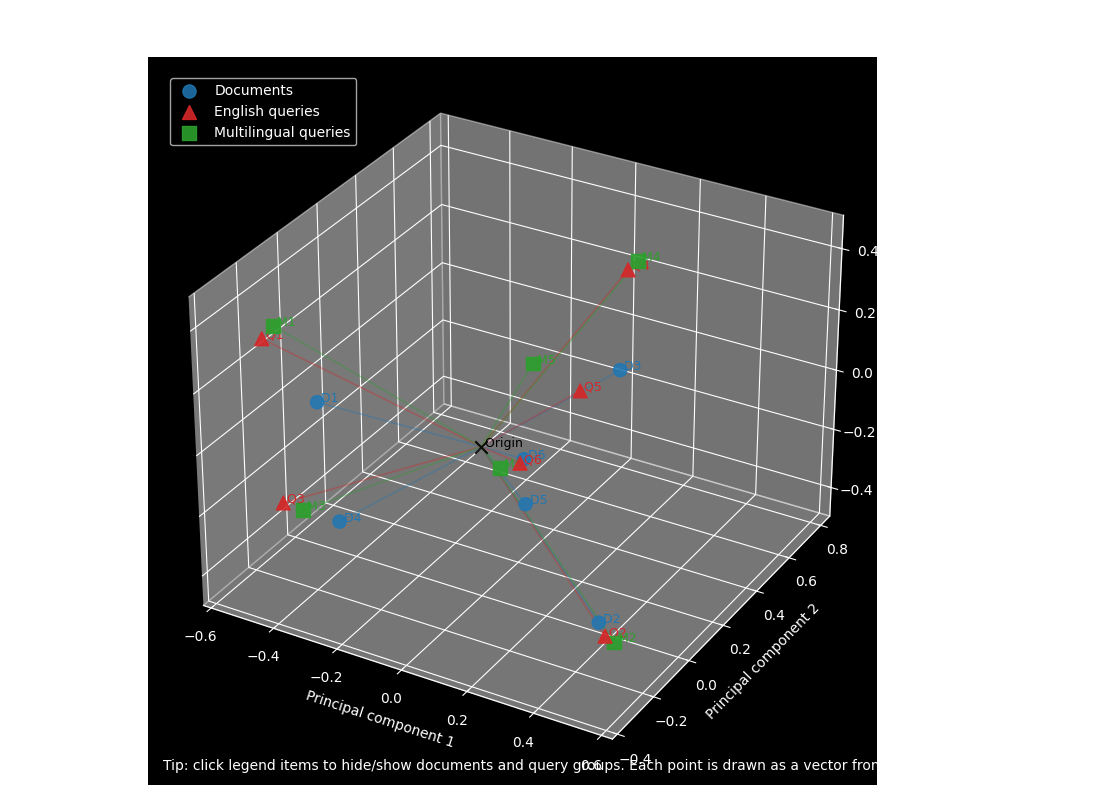

Saved interactive HTML visualization to: /Users/sarbjit/repos/embedding-demo/embedding-vectors-visualization.html
Point labels used in the plot:
--------------------------------------------------------------------------------
D1: The Eiffel Tower is located in Paris and was completed in 1889.
D2: Photosynthesis allows plants to convert sunlight, water, and carbon dioxide into energy.
D3: Python is a popular programming language used for web development, data science, and automation.
D4: Mount Everest is the highest mountain above sea level on Earth.
D5: Octopuses are highly intelligent marine animals with eight arms and remarkable camouflage abilities.
D6: Basketball is a team sport in which players score points by shooting a ball through a hoop.
Q1: Where is the Eiffel Tower located?
Q2: How do plants make food from sunlight?
Q3: What is the tallest mountain in the world?
Q4: Tell me about the Python programming language.
Q5: How do you bake sourdough bread?
Q6: What causes thundersto

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pathlib import Path
from matplotlib.backend_bases import Event

from IPython import get_ipython


ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
    except Exception:
        # Fallback for environments where the widget backend is unavailable.
        try:
            ip.run_line_magic("matplotlib", "notebook")
        except Exception:
            pass


def to_numpy(embeddings):
    if hasattr(embeddings, "detach"):
        embeddings = embeddings.detach().cpu().numpy()
    return np.asarray(embeddings, dtype=float)


def reduce_to_3d(vectors):
    vectors = np.asarray(vectors, dtype=float)
    centered = vectors - vectors.mean(axis=0, keepdims=True)

    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    component_count = min(3, vh.shape[0])
    reduced = centered @ vh[:component_count].T

    if reduced.shape[1] < 3:
        reduced = np.pad(reduced, ((0, 0), (0, 3 - reduced.shape[1])), mode="constant")

    return reduced[:, :3]


document_vectors = to_numpy(document_embeddings)
english_query_vectors = to_numpy(query_embeddings)
multilingual_query_vectors = to_numpy(multilingual_query_embeddings)

all_vectors = np.vstack([
    document_vectors,
    english_query_vectors,
    multilingual_query_vectors,
])
projected_vectors = reduce_to_3d(all_vectors)

num_documents = len(documents)
num_english_queries = len(queries)

projected_documents = projected_vectors[:num_documents]
projected_english_queries = projected_vectors[num_documents:num_documents + num_english_queries]
projected_multilingual_queries = projected_vectors[num_documents + num_english_queries:]

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
fig.patch.set_facecolor("white")

origin_marker = ax.scatter([0], [0], [0], c="black", marker="x", s=80, alpha=0.9)
ax.text(0, 0, 0, " Origin", color="black", fontsize=9)

scatter_documents = ax.scatter(
    projected_documents[:, 0],
    projected_documents[:, 1],
    projected_documents[:, 2],
    c="#1f77b4",
    marker="o",
    s=90,
    alpha=0.85,
    label="Documents",
)
scatter_english_queries = ax.scatter(
    projected_english_queries[:, 0],
    projected_english_queries[:, 1],
    projected_english_queries[:, 2],
    c="#d62728",
    marker="^",
    s=100,
    alpha=0.9,
    label="English queries",
)
scatter_multilingual_queries = ax.scatter(
    projected_multilingual_queries[:, 0],
    projected_multilingual_queries[:, 1],
    projected_multilingual_queries[:, 2],
    c="#2ca02c",
    marker="s",
    s=100,
    alpha=0.9,
    label="Multilingual queries",
)


def draw_vectors(points, color):
    lines = []
    for x, y, z in points:
        (line,) = ax.plot([0, x], [0, y], [0, z], color=color, alpha=0.35, linewidth=1.2)
        lines.append(line)
    return lines


document_lines = draw_vectors(projected_documents, "#1f77b4")
english_query_lines = draw_vectors(projected_english_queries, "#d62728")
multilingual_query_lines = draw_vectors(projected_multilingual_queries, "#2ca02c")

point_catalog = []
document_labels = []
for index, coords in enumerate(projected_documents, start=1):
    tag = f"D{index}"
    point_catalog.append((tag, documents[index - 1]))
    label = ax.text(coords[0], coords[1], coords[2], f" {tag}", color="#1f77b4", fontsize=9)
    document_labels.append(label)

english_query_labels = []
for index, coords in enumerate(projected_english_queries, start=1):
    tag = f"Q{index}"
    point_catalog.append((tag, queries[index - 1]))
    label = ax.text(coords[0], coords[1], coords[2], f" {tag}", color="#d62728", fontsize=9)
    english_query_labels.append(label)

multilingual_query_labels = []
for index, coords in enumerate(projected_multilingual_queries, start=1):
    tag = f"M{index}"
    point_catalog.append((tag, multilingual_queries[index - 1]))
    label = ax.text(coords[0], coords[1], coords[2], f" {tag}", color="#2ca02c", fontsize=9)
    multilingual_query_labels.append(label)

ax.set_title("3D Visualization of Document and Query Embeddings", pad=20)
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.set_zlabel("Principal component 3")
ax.grid(True, alpha=0.3)

legend = ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98))
legend_handles = getattr(legend, "legendHandles", None) or getattr(legend, "legend_handles", None)
legend_items = {
    legend_handles[0]: {
        "scatter": scatter_documents,
        "lines": document_lines,
        "labels": document_labels,
    },
    legend_handles[1]: {
        "scatter": scatter_english_queries,
        "lines": english_query_lines,
        "labels": english_query_labels,
    },
    legend_handles[2]: {
        "scatter": scatter_multilingual_queries,
        "lines": multilingual_query_lines,
        "labels": multilingual_query_labels,
    },
}

for legend_item in legend_items:
    legend_item.set_picker(True)


def toggle_series(event: Event):
    legend_item = getattr(event, "artist", None)
    if legend_item not in legend_items:
        return

    target_group = legend_items[legend_item]
    is_visible = not target_group["scatter"].get_visible()
    target_group["scatter"].set_visible(is_visible)
    for line in target_group["lines"]:
        line.set_visible(is_visible)
    for label in target_group["labels"]:
        label.set_visible(is_visible)
    legend_item.set_alpha(1.0 if is_visible else 0.25)
    fig.canvas.draw_idle()


fig.canvas.mpl_connect("pick_event", toggle_series)
ax.text2D(
    0.02,
    0.02,
    "Tip: click legend items to hide/show documents and query groups. Each point is drawn as a vector from the origin.",
    transform=ax.transAxes,
    fontsize=10,
)

plt.tight_layout()
plt.show()


def add_plotly_group(fig, name, points, labels, descriptions, color, symbol):
    line_x, line_y, line_z = [], [], []
    for x, y, z in points:
        line_x.extend([0, x, None])
        line_y.extend([0, y, None])
        line_z.extend([0, z, None])

    fig.add_trace(
        go.Scatter3d(
            x=line_x,
            y=line_y,
            z=line_z,
            mode="lines",
            line={"color": color, "width": 4},
            name=f"{name} vectors",
            legendgroup=name,
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers+text",
            text=labels,
            textposition="top center",
            marker={"size": 6, "color": color, "symbol": symbol},
            name=name,
            legendgroup=name,
            customdata=np.array(descriptions, dtype=object),
            hovertemplate="<b>%{text}</b><br>%{customdata}<extra></extra>",
        )
    )


plotly_fig = go.Figure()
plotly_fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="markers+text",
        text=["Origin"],
        textposition="top center",
        marker={"size": 5, "color": "black", "symbol": "x"},
        name="Origin",
        hovertemplate="<b>Origin</b><extra></extra>",
    )
)

add_plotly_group(
    plotly_fig,
    "Documents",
    projected_documents,
    [f"D{index}" for index in range(1, len(projected_documents) + 1)],
    documents,
    "#1f77b4",
    "circle",
)
add_plotly_group(
    plotly_fig,
    "English queries",
    projected_english_queries,
    [f"Q{index}" for index in range(1, len(projected_english_queries) + 1)],
    queries,
    "#d62728",
    "diamond",
)
add_plotly_group(
    plotly_fig,
    "Multilingual queries",
    projected_multilingual_queries,
    [f"M{index}" for index in range(1, len(projected_multilingual_queries) + 1)],
    multilingual_queries,
    "#2ca02c",
    "square",
)

plotly_fig.update_layout(
    title="Interactive 3D Visualization of Document and Query Embeddings",
    legend={"groupclick": "togglegroup"},
    scene={
        "xaxis_title": "Principal component 1",
        "yaxis_title": "Principal component 2",
        "zaxis_title": "Principal component 3",
    },
    margin={"l": 0, "r": 0, "b": 0, "t": 40},
)

html_output_path = Path("embedding-vectors-visualization.html")
plotly_fig.write_html(html_output_path, include_plotlyjs=True, full_html=True)
print(f"Saved interactive HTML visualization to: {html_output_path.resolve()}")

print("Point labels used in the plot:")
print("-" * 80)
for tag, text in point_catalog:
    print(f"{tag}: {text}")


## <span style="color: gold;">Interactive Demo</span>

**Notes**
* I would like to present an interactive demo to my audience.
* Where I am prompted to enter a query and then the code returns the most relevant document.

**Instructions**
1. Present a nice dialog box to the user to enter a query
2. Encode the query using the same embedding model and compute the similarity with the document embeddings
3. Return the most relevant document only, showing the cosine similarity score for the match


In [17]:
import ipywidgets as widgets
from IPython.display import display

WIDGET_WIDTH = "640px"
FONT = "Monaco, 'Cascadia Code', 'Fira Code', 'Consolas', 'Menlo', monospace"

query_input = widgets.Text(
    placeholder="e.g. Where is the Eiffel Tower?",
    layout=widgets.Layout(flex="1 1 auto", font_family=FONT),
    style={"font_size": "13px"},
)

submit_button = widgets.Button(
    description="Search",
    button_style="primary",
    icon="search",
    layout=widgets.Layout(width="110px", flex="0 0 auto"),
    style={"font_size": "13px", "font_family": FONT},
)

result_html = widgets.HTML(
    value="",
    layout=widgets.Layout(
        width="100%",
        padding="12px",
        border="1px solid #ccc",
        border_radius="6px",
        min_height="60px",
        box_sizing="border-box",
    ),
)

input_row = widgets.HBox(
    [query_input, submit_button],
    layout=widgets.Layout(width="100%"),
)

container = widgets.VBox(
    [
        widgets.HTML(
            f"<div style=\"font-family:Monaco, 'Cascadia Code', 'Fira Code', 'Consolas', 'Menlo', monospace;\">"
            "<b style='font-size:15px;'>\U0001f50e Interactive Document Search</b>"
            "<br><span style='color:#555; font-size:13px;'>Type a query and press Enter or click Search.</span>"
            "</div>"
        ),
        input_row,
        result_html,
    ],
    layout=widgets.Layout(
        width=WIDGET_WIDTH,
        padding="16px",
        border="1px solid #ddd",
        border_radius="8px",
        gap="10px",
    ),
)


def on_search(change):
    query = query_input.value.strip()
    if not query:
        result_html.value = (
            f"<span style=\"font-family:Monaco, 'Cascadia Code', 'Fira Code', 'Consolas', 'Menlo', monospace; color:#e67e00;\">\u26a0\ufe0f&nbsp; Please enter a query before clicking Search.</span>"
        )
        return

    result_html.value = f"<span style=\"font-family:Monaco, 'Cascadia Code', 'Fira Code', 'Consolas', 'Menlo', monospace; color:#888;\">\u23f3&nbsp; Searching\u2026</span>"

    encoded_query = model.encode([query], prompt_name="query")
    scores = model.similarity(encoded_query, document_embeddings)[0].tolist()
    best_index = max(range(len(scores)), key=scores.__getitem__)
    best_score = scores[best_index]

    result_html.value = (
        f"<div style=\"font-family:Monaco, 'Cascadia Code', 'Fira Code', 'Consolas', 'Menlo', monospace; font-size:13px; line-height:1.7; word-wrap:break-word; overflow-wrap:break-word;\">"
        f"<div>\U0001f50d <b>Query:</b>&nbsp;{query}</div>"
        "<hr style=\"border:none; border-top:1px solid #eee; margin:6px 0;\">"
        f"<div>\U0001f4c4 <b>Best match:</b>&nbsp;{documents[best_index]}</div>"
        f"<div>\U0001f4ca <b>Similarity:</b>&nbsp;{best_score:.4f}</div>"
        "</div>"
    )


## <span style="color: gold;">Dialog Box</span>

In [18]:
submit_button.on_click(on_search)
query_input.on_submit(on_search)

display(container)


/var/folders/hf/nwv75x5s507cz9wvrygp32v40000gn/T/ipykernel_15328/463795058.py:2: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  query_input.on_submit(on_search)
